Program: Professional Certificate in Data Science,Machine Learning & AI Module: Unsupervised Machine Learning Methods Techniques: K-means Clustering, Principal Component Analysis(PCA)

Instructor: Lumumba W. Victor Email: lumumbavictor172@gmail.com

Dataset: medical_clustering_data.csv Date Issued: April 24, 2026

Student: KIBIDI K. LERENCER Reg no: CDAM/0047/2026

 **2.1 Task 1: Data Import and Initial Exploration**

In [1]:
#2.1.1 Load required libraries

from google.colab import files
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#2.1.2a: Import medical_clustering_data.csv

from google.colab import files
uploaded = files.upload()

df = pd.read_csv('medical_clustering_data.csv')


TypeError: 'NoneType' object is not subscriptable

In [ ]:
#2.1.2b: Display first 6 rows

df.head()

In [ ]:
#2.1.2c: Display dataset structure

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 220 entries, 0 to 219
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   patient_id                  220 non-null    object 
 1   age                         220 non-null    int64  
 2   sex                         220 non-null    object 
 3   bmi                         202 non-null    float64
 4   waist_cm                    202 non-null    float64
 5   bp_systolic                 220 non-null    float64
 6   bp_diastolic                220 non-null    int64  
 7   heart_rate                  220 non-null    int64  
 8   cholesterol_total           220 non-null    float64
 9   cholesterol_hdl             202 non-null    float64
 10  cholesterol_ldl             220 non-null    float64
 11  triglycerides               202 non-null    float64
 12  glucose_fasting             202 non-null    float64
 13  hba1c                       202 non

In [ ]:
#2.1.3: Report missing value counts and percentages per variable

missing_summary = df.isnull().sum().to_frame(name='missing')
missing_summary['Percent'] = 100 * missing_summary['missing'] / len(df)
print(missing_summary[missing_summary['missing'] > 0])

                            missing   Percent
bmi                              18  8.181818
waist_cm                         18  8.181818
cholesterol_hdl                  18  8.181818
triglycerides                    18  8.181818
glucose_fasting                  18  8.181818
hba1c                            18  8.181818
crp                              18  8.181818
physical_activity_min_week       18  8.181818


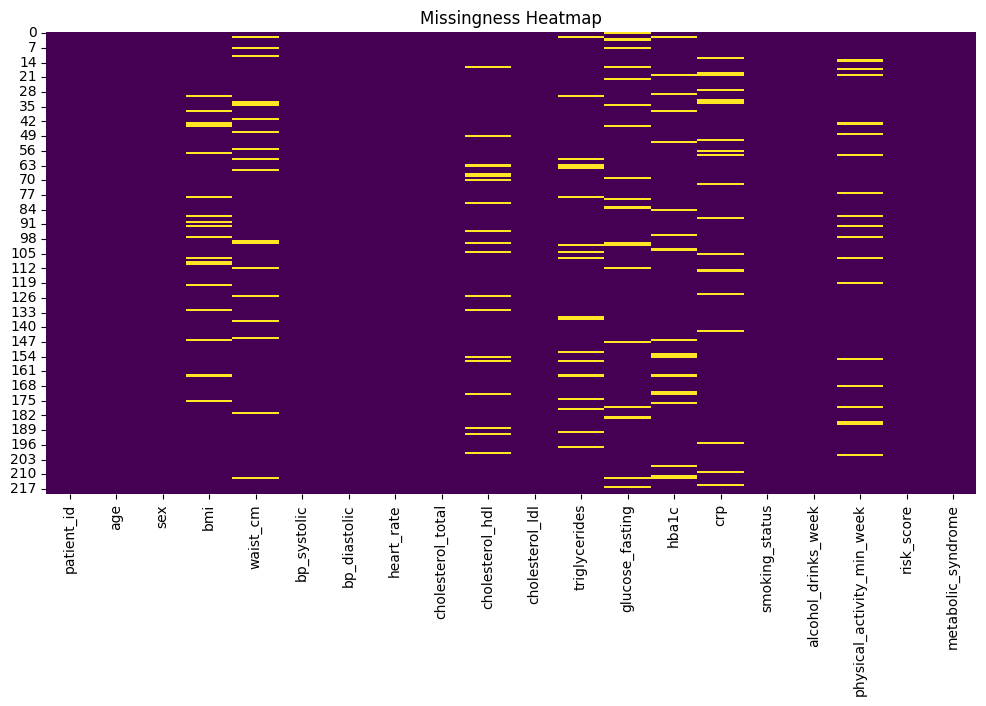

In [ ]:
#2.1.4: Create a missingness heatmap  on the boolean missingness matrix.

plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Missingness Heatmap')
plt.show()

The variables BME, Waist, cholestrol hdl, tryglycerides, fasting gllucose, hbac, crp and physical activity in week are the most affected variables issing 18 obsevations each totaling to 8.2% of missing data

In [ ]:
# 2.1.5: univariate summaries for all numeric variables

df.describe()

,age,bmi,waist_cm,bp_systolic,bp_diastolic,heart_rate,cholesterol_total,cholesterol_hdl,cholesterol_ldl,triglycerides,glucose_fasting,hba1c,crp,alcohol_drinks_week,physical_activity_min_week,risk_score,metabolic_syndrome
count,220.000000,202.000000,202.000000,220.000000,220.000000,220.000000,220.000000,202.000000,220.000000,202.000000,202.000000,202.000000,202.000000,220.000000,202.000000,220.000000,220.00000
mean,52.409091,28.871287,139.034653,136.514091,86.504545,70.936364,196.874545,48.002970,115.548182,83.545050,105.610693,5.438317,2.020856,4.468182,192.787129,6.680909,0.50000
std,13.722824,11.280907,3.190360,57.619915,13.103904,11.960572,39.952441,13.344248,42.221077,58.220374,46.770429,0.628907,2.925588,2.150478,215.468342,3.417134,0.50114
min,18.000000,16.000000,123.200000,90.000000,55.000000,50.000000,81.800000,9.200000,40.000000,15.100000,60.000000,4.000000,0.070000,0.000000,8.000000,0.000000,0.00000
25%,42.000000,23.550000,140.000000,116.000000,77.000000,62.000000,170.225000,39.075000,87.350000,44.125000,86.050000,5.042500,0.472500,3.000000,53.000000,4.575000,0.00000
50%,52.000000,28.250000,140.000000,126.000000,86.000000,70.000000,196.250000,48.250000,115.200000,69.550000,100.750000,5.400000,1.000000,4.000000,108.000000,6.500000,0.50000
75%,61.000000,31.275000,140.000000,139.000000,95.000000,80.000000,222.600000,56.475000,144.725000,107.175000,115.175000,5.875000,2.262500,6.000000,242.250000,8.625000,1.00000
max,85.000000,125.460000,140.000000,508.800000,120.000000,101.000000,306.000000,82.400000,220.300000,447.720000,442.560000,6.930000,28.690000,11.000000,1000.000000,20.300000,1.00000


2.2 **Task 2: Data Preprocessing Pipeline**

In [ ]:
#2.2.0:Create a copy for preprocessing
df_clean = df.copy()
df_clean.head()

In [ ]:
#2.2.1: Handling missing values(drop)
df_clean = df_clean.dropna()
print(f"\nRows after removing missing values: {len(df_clean)}")

**Rational for dropping missing values**
Precision medicine requires identifying homogeneous patient subgroups for targeted interventions

In [ ]:
# 2.2.2: Outlier Detection in numerical variables:
# 2.2.2a: Outlier Detection :IQR METHOD


In [ ]:
# 2.2.2b: Outlier Detection :Boxplot visualization top 5 variables with most outliers

In [ ]:
#2.2.3a;Outlier Treatment:

#2.2.3b: Outlier Treatment: justification
Apply winsorization (capping at 1st/99th percentiles using np.percentile) or robust scaling

In [ ]:
#2.2.4: Feature Scaling to all numeric clustering inputs
StandardScaler from sklearn.preprocessing


In [ ]:
#2.2.5: Create medical_clean  with preprocessed numeric features only
 #(exclude patient_id, sex, smoking_status, risk_score, metabolic_syndrome from clustering inputs).

** 2.3 Task 3: Exploratory Data Visualization**

In [ ]:
#2.3.1a: Correlation Heatmap
sns.heatmap()

2.3.b: Correlation Heatmap: Highlight strongest positive pairs.

2.3.1c: Correlation HeatmapHighlight strongest negative pairs.


In [ ]:
#2.3.2a:Pairwise Scatterplot Matrix
sns.pairplot()
pandas.plotting.scatter_matrix()

2.3.2b:Pairwise Scatterplot Matrix: Linear patterns

2.3.2c:Pairwise Scatterplot Matrix: nonlinear patterns